# CS6421 Assignment 2: Autoencoders

This assignment will focus on designing denoising autoencoders.

<a target="_blank" href="https://colab.research.google.com/github/andrew-nash/CS6421-labs-2025/blob/main/CS6421_Assignment_02.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Due on  20/03/2025 at 23:59:59 UTC

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implementing A CNN-Based Denoising Auto-encoder

For task 1, we will fit a denoising autoencoder to the MNIST data.

We will train the autoencoder by fitting noisy inputs against clean outputs. We will manually add the noise to the inoputs

### Data

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

np.random.seed(42)
x_train_noisy = x_train + np.random.normal(loc=0.0, scale=0.75, size=x_train.shape)
x_test_noisy = x_test + np.random.normal(loc=0.0, scale=0.75, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


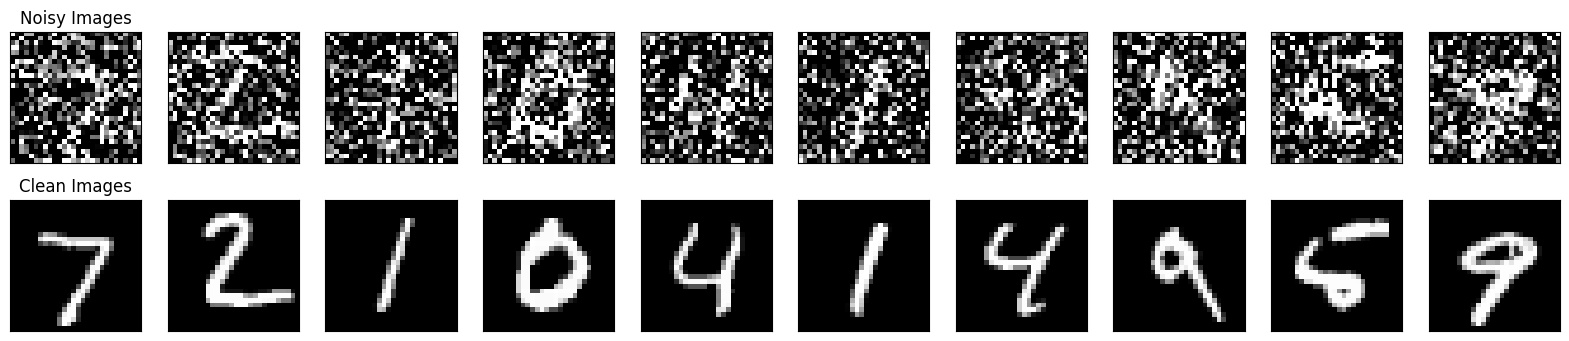

In [3]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
      ax.set_title('Noisy Images')
for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Clean Images')

plt.show()


In [4]:
class AutoEncoder(tf.keras.models.Model):
  def __init__(self):
    super(AutoEncoder, self).__init__()
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
      tf.keras.layers.Conv2D(8, (2, 2), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    ])

    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
       tf.keras.layers.Conv2D(1,(3,3),strides=(1,1),activation='relu',padding='same'),
      ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AutoEncoder()

autoencoder.compile(optimizer='adam', loss='mse')



tensorboard_callback = tf.keras.callbacks.TensorBoard(f"./tboard/dense_basic", histogram_freq=1)
autoencoder.fit(x_train_noisy, x_train,
          epochs=10,
          batch_size=512,
          validation_split=0.8,
          shuffle=True, callbacks=[tensorboard_callback])

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - loss: 0.1046 - val_loss: 0.0909
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 913ms/step - loss: 0.0889 - val_loss: 0.0763
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - loss: 0.0705 - val_loss: 0.0521
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 793ms/step - loss: 0.0495 - val_loss: 0.0463
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 832ms/step - loss: 0.0451 - val_loss: 0.0437
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 806ms/step - loss: 0.0428 - val_loss: 0.0417
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0407 - val_loss: 0.0398
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 786ms/step - loss: 0.0391 - val_loss: 0.0384
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0375 - val_loss: 0.0373
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0366 - val_loss: 0.0365


When defining a CNN-based autoencoder, you have to pay carfeul attention to the `strides`, to make sure that the input and output dimensions are the same.

The last layer can be a Conv2D or a Conv2DTranspose - so long as it only has a single filter, to correspond to the single channel in the input image.

In [5]:
autoencoder.encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 680 (2.66 KB)

 Trainable params: 680 (2.66 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 1)           │              73 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,241 (4.85 KB)

 Trainable params: 1,241 (4.85 KB)

 Non-trainable params: 0 (0.00 B)

#### Visualizations

Compare, original, noisy and reconstructed outputs:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


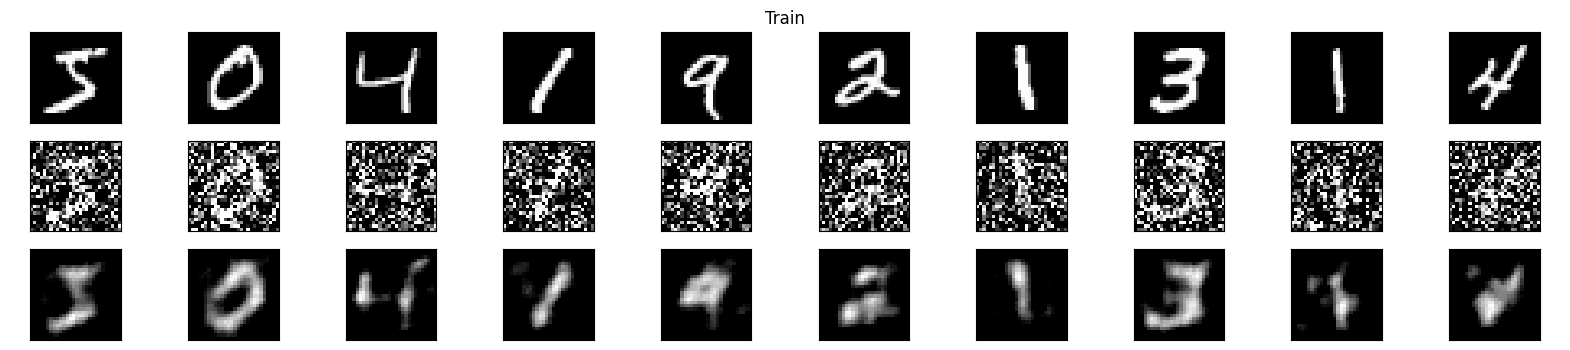

In [7]:
n = 10
decoded_imgs = autoencoder.predict(x_train_noisy[:n])

plt.figure(figsize=(20, 4))
plt.title("Train")
plt.axis('off')
for i in range(10):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


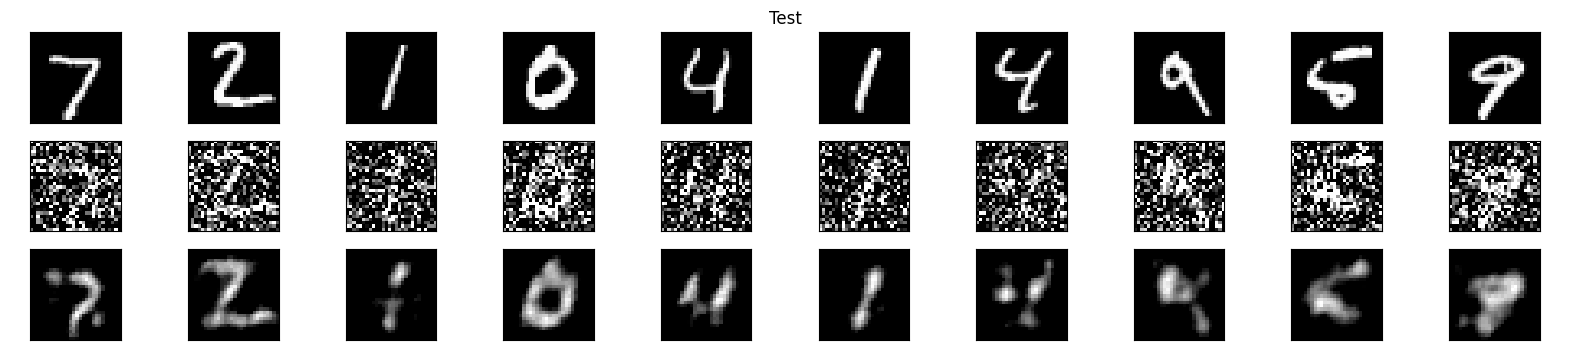

In [8]:
n = 10
decoded_imgs = autoencoder.predict(x_test_noisy[:n])

plt.figure(figsize=(20, 4))
plt.title("Test")
plt.axis('off')
for i in range(10):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

### Exercise 1

1. Adjust the autoencoder to have **at least 2** other different bottleneck sizes, one larger and one smaller than the given dimensions. In the given example above, this dimension is (None, 4, 4, 8)->4x4x8=128.

2. You may (and should) spend a little time tuning the model hyper-parameters to try to achieve good results on each.

3. Visualize the results of applying each model to some samples from the train and test sets.

4. Write a brief discussion of your results comparing the performance of each model, with justufiction as to **why** you think these results occurred

In [ ]:
### CODE ....

In [9]:
# Smaller bottleneck

class AutoEncoderSmall(tf.keras.models.Model):
    def __init__(self):
        super(AutoEncoderSmall, self).__init__()
        # We reduce filters and/or add an extra pooling to shrink the latent space
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Conv2D(8, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            tf.keras.layers.Conv2D(4, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            # Optionally add another pooling to shrink further, but be mindful
            # of reconstruction difficulty if the dimension is too small.
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(4, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(8, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded




In [11]:
# larger bottleneck

class AutoEncoderLarge(tf.keras.models.Model):
    def __init__(self):
        super(AutoEncoderLarge, self).__init__()
        # Increase number of filters (and/or reduce pooling) to inflate the latent dimension
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            # Could remove or modify a pooling layer to further enlarge the bottleneck
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(16, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(32, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [13]:
# initialisation

autoencoder_small    = AutoEncoderSmall()
autoencoder_large    = AutoEncoderLarge()

autoencoder_small.compile(optimizer='adam', loss='mse')
autoencoder_large.compile(optimizer='adam', loss='mse')

In [14]:
# training


EPOCHS = 10
BATCH_SIZE = 512
VALIDATION_SPLIT=0.8


print("Training Small-Bottleneck AutoEncoder...")
history_small = autoencoder_small.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)

print("Training Large-Bottleneck AutoEncoder...")
history_large = autoencoder_large.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)


Training Small-Bottleneck AutoEncoder...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 949ms/step - loss: 0.2275 - val_loss: 0.2065
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 0.1891 - val_loss: 0.1254
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.1214 - val_loss: 0.1145
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 754ms/step - loss: 0.1156 - val_loss: 0.1127
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.1141 - val_loss: 0.1107
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.1112 - val_loss: 0.1051
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 784ms/step - loss: 0.1040 - val_loss: 0.0968
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0957 - val_loss: 0.0872
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.0854 - val_loss: 0.0772
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0756 - val_loss: 0.0692
Training Large-Bottleneck AutoEncoder...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - loss: 0.2165 - v

In [17]:
# visualisation function
def display_denoising_results(models, x_noisy, x_clean, n=5):
    """
   models: dict of name -> model
    x_noisy: noisy input images
    x_clean: original clean images
    n: number of samples to visualize
    """
    plt.figure(figsize=(12, 4*len(models)))
    random_indices = np.random.randint(0, x_noisy.shape[0], size=n)

    # For each model, show a row of original/noisy/reconstructed
    row = 0
    for model_name, model in models.items():
        reconstructed = model.predict(x_noisy[random_indices])
        for i, idx in enumerate(random_indices):
            plt.subplot(len(models), n*3, row*n*3 + 3*i + 1)
            plt.imshow(x_clean[idx].reshape(28,28), cmap='gray')
            plt.title("Original")
            plt.axis('off')

            plt.subplot(len(models), n*3, row*n*3 + 3*i + 2)
            plt.imshow(x_noisy[idx].reshape(28,28), cmap='gray')
            plt.title("Noisy")
            plt.axis('off')

            plt.subplot(len(models), n*3, row*n*3 + 3*i + 3)
            plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
            plt.title(f"{model_name} Reconstructed")
            plt.axis('off')
        row += 1
    plt.tight_layout()
    plt.show()

# COMPARE MODELS ON TRAIN OR TEST

models = {
    "Original": AutoEncoder,
    "Small": autoencoder_small,
    "Large": autoencoder_large
}

In [19]:
display_denoising_results(models, x_test_noisy, x_test, n=5)


TypeError: TensorFlowTrainer.predict() missing 1 required positional argument: 'x'

<Figure size 1200x1200 with 0 Axes>

In [ ]:
### FINAL EXPLANATION

## Task 2

For the second task, you must implement a de-noising autoencoder from scratch on a more real-world dataset.

In [ ]:
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/train.zip
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/test.zip
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/train_cleaned.zip
!unzip train.zip
!unzip test.zip
!unzip train_cleaned.zip

--2025-03-13 12:27:00--  https://github.com/gmprovan/CS6421-Assignment1/raw/master/train.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gmprovan/CS6421-Assignment1/master/train.zip [following]
--2025-03-13 12:27:00--  https://raw.githubusercontent.com/gmprovan/CS6421-Assignment1/master/train.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19407030 (19M) [application/zip]
Saving to: ‘train.zip’

train.zip           100%[===================>]  18.51M  --.-KB/s    in 0.08s   

2025-03-13 12:27:01 (231 MB/s) - ‘train.zip’ saved [19407030/19407030]

--2025-03-13 12:27:01--  https://github.co

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, array_to_img, img_to_array
import os
from sklearn.model_selection import train_test_split

X = []
Y = []

for img in os.listdir("train"):
    img = tf.keras.utils.load_img(f"train/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    X.append(img)

for img in os.listdir("train_cleaned"):
    img = load_img(f"train_cleaned/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    Y.append(img)


X = np.array(X)
Y = np.array(Y)

x_train, x_valid, y_train, y_valid = train_test_split(X, Y, test_size=0.1, random_state=111)

X = []

for img in os.listdir("test"):
    img = tf.keras.utils.load_img(f"test/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    X.append(img)

x_test = np.array(X)

This dataset consists of scans of text documents that contain noise and artificats.

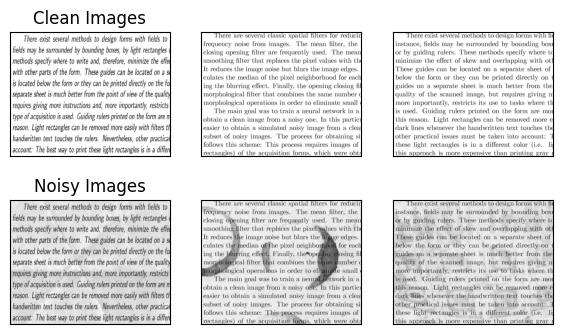

In [ ]:
n = 3
plt.figure(figsize=(7, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(y_train[i].reshape(420, 540))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
      ax.set_title('Clean Images')
for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train[i].reshape(420, 540))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Noisy Images')

plt.show()


## Exercise 2

1. Implement a denoising CNN autoencoder on this data, observing that the size of your images are now  (420, 540, 1). Use MSE loss. These models will take longer to train, to try to start from what you expect to be a good starting set of hyper-parametrers. Try to make the bottleneck as small as possible.
2. Visualise the results of applying this autoencoder on the train and test data for different autoencoder sizes - focusing particularly on the bottleneck size.
3. A small number of marks are available for implementing the correct regularization on this model
4. Discuss and explain the performances of differnt models and bottleneck sizes similarly to task 1.